# 2 &middot; LPT Lightcone Simulation

Notebook 1 painted a static particle set. Here we add **gravity** at the cheapest level:
first-order Lagrangian Perturbation Theory (the Zel'dovich approximation), which displaces
particles from their Lagrangian grid positions $\mathbf q$ to Eulerian positions

$$\mathbf x(a) = \mathbf q + D(a)\,\boldsymbol\Psi(\mathbf q).$$

Instead of one snapshot we build a **lightcone**: `lpt` is asked for `nb_shells` radial shells
and paints each one onto a HEALPix map at its own scale factor. We then

1. compare the measured angular power spectrum $C_\ell$ to linear theory, and
2. recover the small-scale signal by **deconvolving the pixel window** and **subtracting shot
   noise** &mdash; the standard corrections for a particle-sampled field.

## Setup

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import healpy as hp

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Parameters

In [2]:
key = jax.random.PRNGKey(0)
mesh_size = (400, 400, 400)   # large mesh -> shells comfortably above min_width
box_size = (800.0, 800.0, 800.0)   # large box -> shells comfortably above min_width
nside = 256
nb_shells = 3
cosmo = jc.Planck18()
LMAX = 2 * nside                       # stay inside the reliable transform band
ells = jnp.arange(LMAX)

## Initial conditions

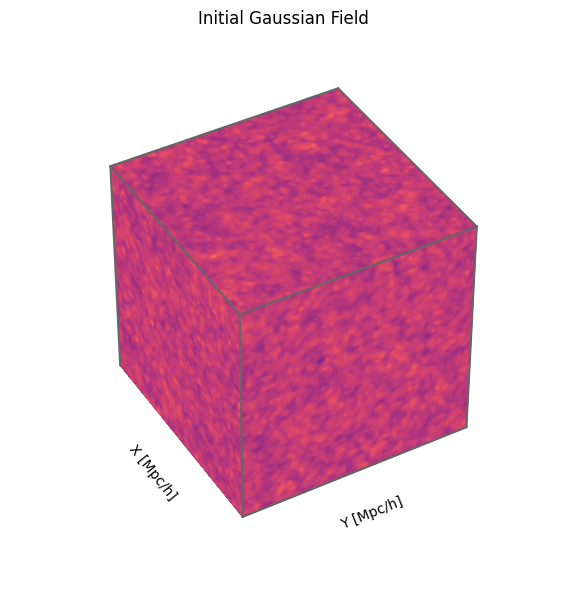

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key, mesh_size, box_size, cosmo=cosmo, nside=nside,
)
initial_field.show(labels=["X [Mpc/h]", "Y [Mpc/h]", ""], colorbar=False,
                   titles=["Initial Gaussian Field"])

## LPT on a lightcone

Passing `nb_shells` (instead of a scalar `ts`) tells `lpt` to build a lightcone. Under the hood
`jfli.resolve_geometry` slices the comoving volume between the observer and the box boundary
into shells (respecting `min_width`), evaluates the Zel'dovich displacement at each shell's
scale factor, and paints the particles that fall inside it.

We paint with the **`ngp`** scheme: nearest-grid-point has a closed-form HEALPix pixel window,
which is exactly what we will deconvolve below (`bilinear` has no closed form).

In [4]:
spherical_dens, _ = jfli.lpt(
    cosmo, initial_field, nb_shells=nb_shells, order=1,
    painting=jfli.PaintingOptions(target="spherical", scheme="ngp"),
)
a_shells = np.asarray(spherical_dens.scale_factors).ravel()
z_shells = np.asarray(jc.utils.a2z(jnp.asarray(a_shells)))
r_shells = np.asarray(spherical_dens.comoving_centers).ravel()
print(f"output : {type(spherical_dens).__name__}  shape={spherical_dens.shape}  nside={spherical_dens.nside}")
for i, (z, r) in enumerate(zip(z_shells, r_shells)):
    print(f"  shell {i}: z = {z:.3f},  comoving distance = {r:.0f} Mpc/h")

output : SphericalDensity  shape=(3, 49152)  nside=64
  shell 0: z = 0.022,  comoving distance = 67 Mpc/h
  shell 1: z = 0.068,  comoving distance = 200 Mpc/h
  shell 2: z = 0.114,  comoving distance = 333 Mpc/h


### The shells

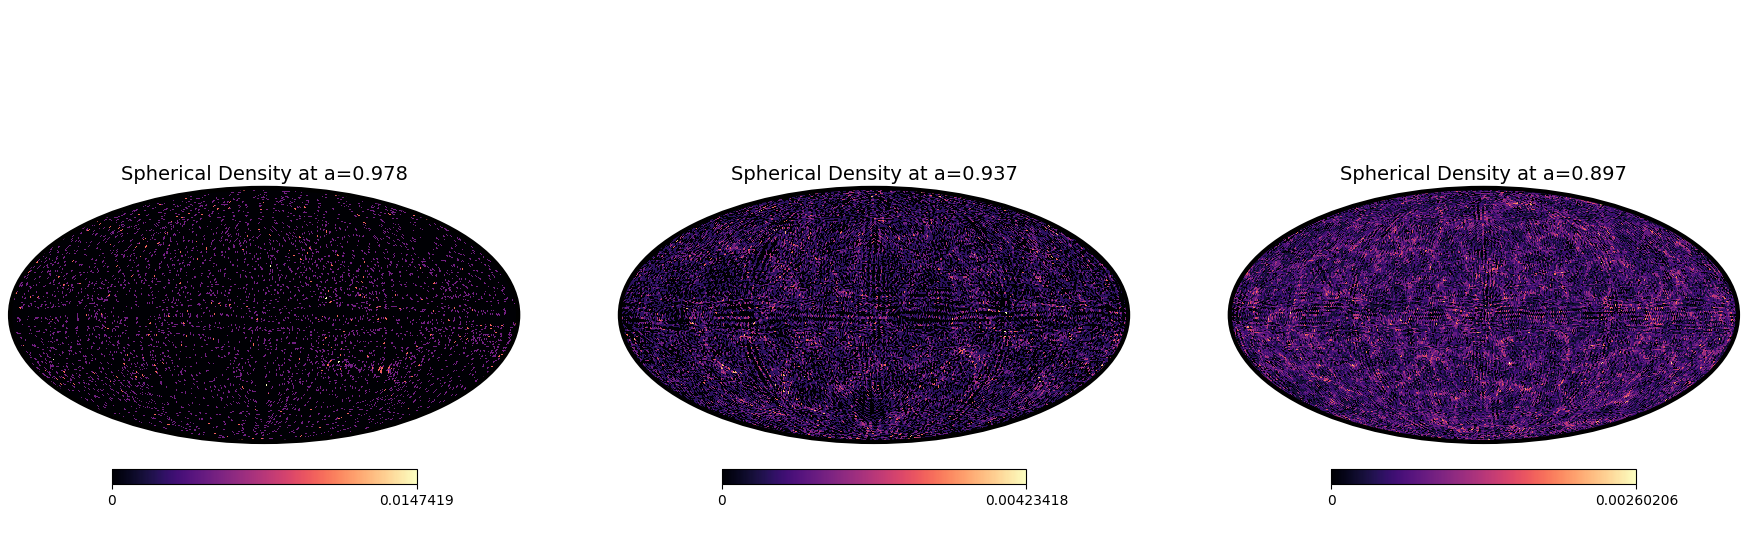

In [5]:
spherical_dens.apply_fn(jnp.log1p).show(ncols=3)

## Comparison to linear theory

`compute_theory_cl_for_density` predicts the angular power spectrum of each shell from its
redshift kernel. For the measurement we convert the painted **counts** to **overdensity** with
`normalization="per_plane"` &mdash; each shell is normalised by *its own* mean, which is the
right choice on a lightcone where shells at different distances hold different numbers of
particles.

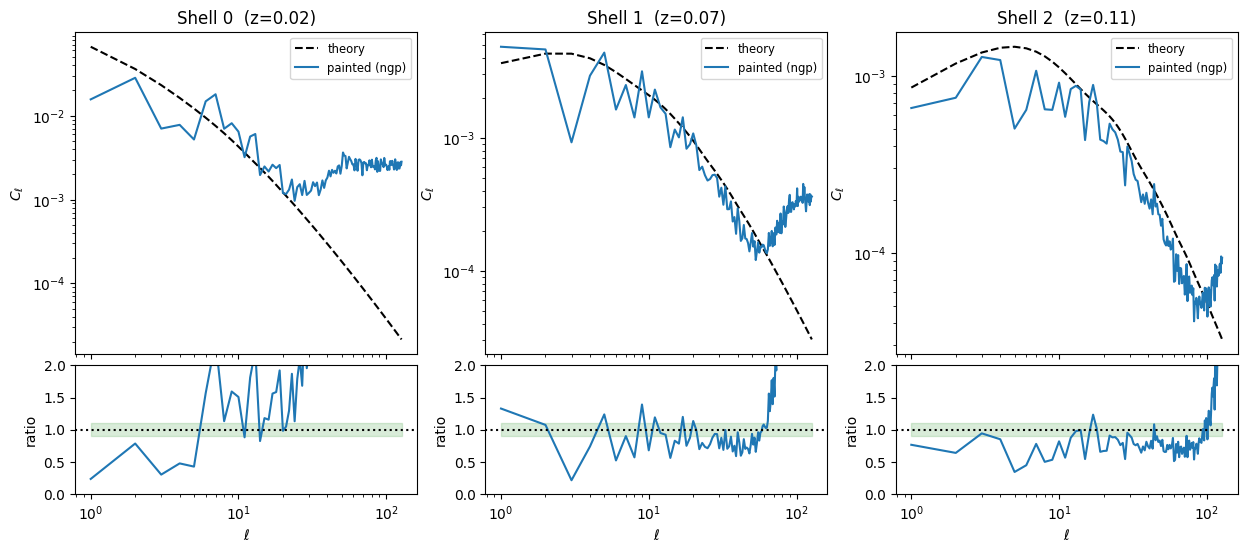

In [6]:
cl_theory = jfli.compute_theory_cl_for_density(
    cosmo, spherical_dens, ells=ells,
    nonlinear_fn=jc.power.linear_matter_power, nz_zmax=1.0,
)
cl_raw = spherical_dens.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(
    method="healpy", lmax=LMAX - 1,
)

th = np.asarray(cl_theory.array)
raw = np.asarray(cl_raw.array)
L = np.arange(1, LMAX)

fig, axes = plt.subplots(2, nb_shells, figsize=(5 * nb_shells, 6), sharex="col",
                         gridspec_kw={"height_ratios": [2.5, 1], "hspace": 0.05})
for i in range(nb_shells):
    axes[0, i].loglog(L, th[i, 1:], "k--", label="theory")
    axes[0, i].loglog(L, raw[i, 1:], color="C0", label="painted (ngp)")
    axes[0, i].set_title(f"Shell {i}  (z={z_shells[i]:.2f})")
    axes[0, i].set_ylabel(r"$C_\ell$"); axes[0, i].legend(fontsize="small")
    axes[1, i].semilogx(L, raw[i, 1:] / th[i, 1:], color="C0")
    axes[1, i].axhline(1, color="k", ls=":"); axes[1, i].set_ylim(0, 2)
    axes[1, i].fill_between(L, 0.9, 1.1, alpha=0.15, color="green")
    axes[1, i].set_xlabel(r"$\ell$"); axes[1, i].set_ylabel("ratio")
plt.tight_layout(); plt.show()

The painted spectrum (blue) **falls below** theory at high $\ell$ (the pixel window smooths the map) and **plateaus** at a constant floor (Poisson shot noise from sampling the field with a finite number of particles). The pixel window is a *deterministic* window we deconvolve below; the plateau is shot noise, which in inference is **forward-modelled** (added to the theory prediction) rather than subtracted from the data.

## Window deconvolution

Painting samples the field onto a finite HEALPix grid, which convolves it with the **pixel window** $W_\ell^{\rm pix}$ (here for `scheme="ngp"`) &mdash; the deterministic suppression seen above. `SphericalDensity.deconvolve("ngp")` removes one factor of $W_\ell$ at the $a_{\ell m}$ level (`map2alm` &rarr; divide by $W_\ell$ &rarr; `alm2map`), so the deconvolved spectrum equals $C_\ell^{\rm signal}$ wherever the signal dominates.

The residual high-$\ell$ **plateau** that remains is Poisson shot noise ($\approx 4\pi/N_{\rm part}$ per shell). We do *not* subtract it: subtracting a mean noise floor only debiases a plot and **cannot recover signal below the noise floor** &mdash; that limit is set by the particle count, not the method. In forward modelling you instead add the window and shot noise to the *theory* and compare in the likelihood (exact, no information lost).

In [7]:
# Shot-noise floor (Poisson): 4*pi / N_particles per shell -- shown as a reference
# line, not subtracted.
N_part = np.asarray(spherical_dens.to(jfli.units.COUNTS).array.sum(axis=-1))
N_shot = 4.0 * np.pi / N_part

# Deconvolve the ngp pixel window (one factor of W_l, at the a_lm level)
deconv = spherical_dens.deconvolve("ngp", lmax=LMAX - 1)
cl_deconv = deconv.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(
    method="healpy", lmax=LMAX - 1,
)
dec = np.asarray(cl_deconv.array)

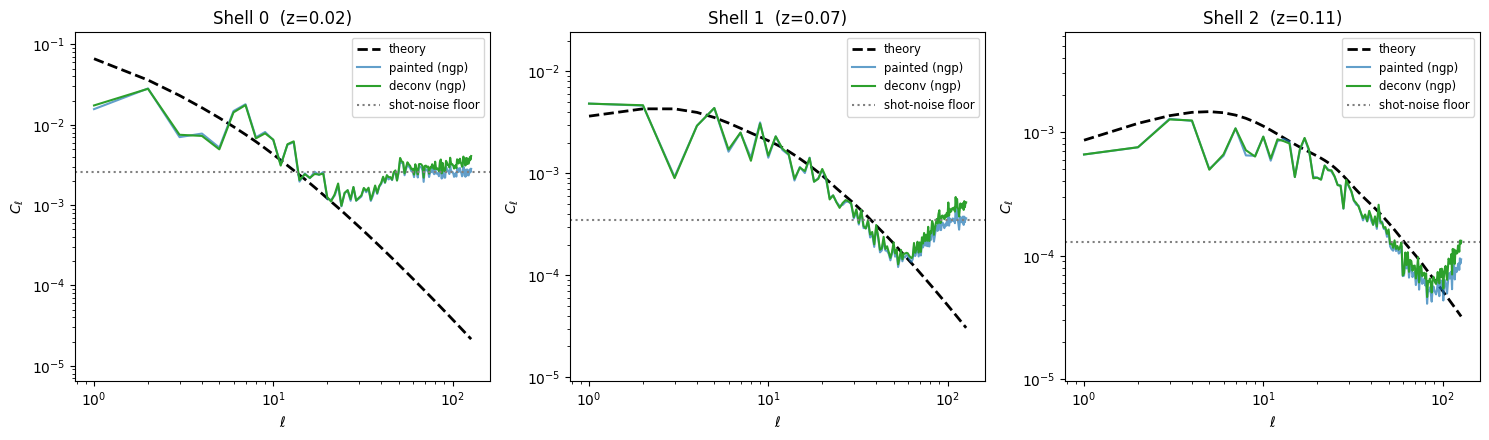

In [8]:
fig, axes = plt.subplots(1, nb_shells, figsize=(5 * nb_shells, 4.5))
for i in range(nb_shells):
    ax = axes[i]
    ax.loglog(L, th[i, 1:], "k--", lw=2, label="theory")
    ax.loglog(L, raw[i, 1:], color="C0", alpha=0.7, label="painted (ngp)")
    ax.loglog(L, dec[i, 1:], color="C2", lw=1.5, label="deconv (ngp)")
    ax.axhline(N_shot[i], color="grey", ls=":", label="shot-noise floor")
    ax.set_title(f"Shell {i}  (z={z_shells[i]:.2f})")
    ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$C_\ell$")
    ax.set_ylim(th[i, 1:].min() * 0.3, raw[i, 1:].max() * 5)
    ax.legend(fontsize="small")
plt.tight_layout(); plt.show()

Deconvolution lifts the high-$\ell$ end back onto theory across the scales where the **signal dominates**; beyond that the painted curve flattens onto the shot-noise floor (grey dotted, $\approx 4\pi/N_{\rm part}$) and the deconvolved curve onto $1/W_\ell^2$ times it. That plateau is sampling noise, not power &mdash; at the production `mesh_size` / `nside` the signal dominates to much higher $\ell$ before it sets in.

## Painting scheme matters: NGP vs RBF

The pixel window above is set by the **mass-assignment scheme**. `scheme="ngp"` (nearest-grid-point) carries only $W_\ell^{\rm pix}$. `scheme="rbf_neighbor"` spreads each particle over a small Gaussian beam $B_\ell$ on top of the pixel window, so its window is $W_\ell^{\rm pix}\,B_\ell$ &mdash; a *smoother* map, suppressed more strongly at high $\ell$.

`deconvolve("rbf_neighbor", kernel_width_arcmin=...)` removes **both** factors $W_\ell^{\rm pix}B_\ell$ (pass the same beam width used at paint time), so the fully deconvolved RBF spectrum climbs onto the signal &mdash; *above* the NGP-raw curve, which still carries $(W_\ell^{\rm pix})^2$. To isolate the beam we also show a **beam-only** correction $C_\ell^{\rm rbf}/B_\ell^2$, which strips just $B_\ell$ and should fall back onto NGP-raw.

In [9]:
# RBF Gaussian beam specified directly in HEALPix pixels via the new
# kernel_width_pixels API (no nside-dependent arcmin conversion needed, nothing to
# restore). 0.8 is a gentle *sub-pixel* beam.
beam_pixels = 0.8
rbf_kw = dict(kernel_width_pixels=beam_pixels, smoothing_interpretation="fwhm")

# paint the SAME lightcone with the RBF scheme (Gaussian beam on top of the pixel window)
rbf_dens, _ = jfli.lpt(
    cosmo, initial_field, nb_shells=nb_shells, order=1,
    painting=jfli.PaintingOptions(target="spherical", scheme="rbf_neighbor", **rbf_kw),
)
cl_rbf_raw = rbf_dens.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(
    method="healpy", lmax=LMAX - 1,
)
rbf_raw = np.asarray(cl_rbf_raw.array)

# full RBF deconvolution removes pixwin * beam (same pixel units) -> lands on the signal
rbf_deconv = rbf_dens.deconvolve("rbf_neighbor", lmax=LMAX - 1, **rbf_kw)
cl_rbf_dec = rbf_deconv.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(
    method="healpy", lmax=LMAX - 1,
)
rbf_dec = np.asarray(cl_rbf_dec.array)

# beam-only correction: strip just B_ell -> should recover the NGP-raw level. The FWHM in
# radians is beam_pixels * pixel size (hp.nside2resol), matching the painter's convention.
fwhm_rad = beam_pixels * float(hp.nside2resol(nside))
Bl = np.asarray(hp.gauss_beam(fwhm_rad, lmax=LMAX - 1))
rbf_beam_only = rbf_raw / np.clip(Bl[None, :], 1e-3, None) ** 2
print(f"rbf beam = {beam_pixels} pixel FWHM  (sigma = {fwhm_rad / 2.355:.2e} rad at nside={nside})")

rbf beam = 0.8 pixel FWHM  (sigma = 5.43e-03 rad at nside=64)


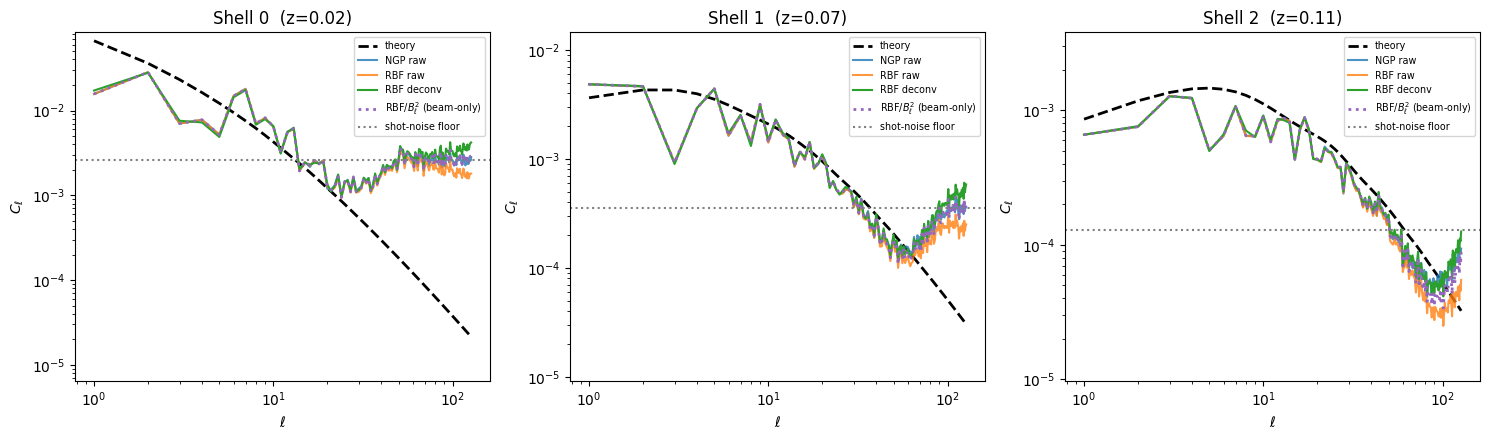

In [10]:
fig, axes = plt.subplots(1, nb_shells, figsize=(5 * nb_shells, 4.5))
for i in range(nb_shells):
    ax = axes[i]
    ax.loglog(L, th[i, 1:], "k--", lw=2, label="theory", zorder=1)
    ax.loglog(L, raw[i, 1:], color="C0", alpha=0.8, label="NGP raw")
    ax.loglog(L, rbf_raw[i, 1:], color="C1", alpha=0.8, label="RBF raw")
    ax.loglog(L, rbf_dec[i, 1:], color="C2", lw=1.5, label="RBF deconv")
    ax.loglog(L, rbf_beam_only[i, 1:], ":", color="C4", lw=2, label=r"RBF$/B_\ell^2$ (beam-only)")
    ax.axhline(N_shot[i], color="grey", ls=":", label="shot-noise floor")
    ax.set_title(f"Shell {i}  (z={z_shells[i]:.2f})")
    ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$C_\ell$")
    ax.set_ylim(th[i, 1:].min() * 0.3, rbf_dec[i, 1:].max() * 3)
    ax.legend(fontsize="x-small")
plt.tight_layout(); plt.show()

**What the plot shows.**

- **RBF raw** (orange) sits *below* NGP raw (blue) at high $\ell$: the extra Gaussian beam $B_\ell$ suppresses small scales on top of the pixel window. This is a gentle **sub-pixel** 0.8-pixel beam ($B_\ell^2 \approx 0.6$ at the band edge), so the gap is modest &mdash; widen `kernel_width_pixels` to separate the curves further.
- **RBF deconv** (green) removes the full $W_\ell^{\rm pix}B_\ell$ window, so it climbs *past* NGP raw and onto the signal; the high-$\ell$ flattening above theory is the residual shot-noise floor (the nominal $4\pi/N_{\rm part}$ is the grey dotted line; forward-modelled in inference, not subtracted here).
- **RBF$/B_\ell^2$** (purple, beam-only) strips *only* the Gaussian beam and overlays NGP raw to ~1% in the signal-dominated regime &mdash; the explicit statement that RBF painting $=$ NGP $\times$ a Gaussian beam. (They part company at the shot-noise floor, where the schemes' discreteness noise differs.)

Because the beam is fixed in **pixels**, its band-edge suppression $B_{\ell\approx2n_{\rm side}}$ is *scale-invariant* &mdash; the RBF$\leftrightarrow$NGP gap reaches the same factor at any resolution; a higher production `nside` just resolves it over more $\ell$-decades. The rule is resolution-independent: **deconvolve with the scheme you painted with** &mdash; `"ngp"` removes $W_\ell^{\rm pix}$, `"rbf_neighbor"` removes $W_\ell^{\rm pix}B_\ell$ (pass the matched `kernel_width_arcmin`).

**Next:** [03 &middot; PM Simulation](03-PM-Simulation.ipynb) replaces the Zel'dovich kick with a full N-body integration, and [07 &middot; Lensing](../2-advanced-usage/07-Lensing.ipynb) turns these shells into weak-lensing maps.